###Bibliotheken einfügen


In [27]:
# import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
import wandb

##Vorverarbeitung

In [29]:
# Vorverarbeitung und filtern
df_goldpreis=pd.read_csv('Goldpreis.csv', index_col=0, parse_dates=True) # einlesen
df_goldpreis.index = pd.to_datetime(df_goldpreis.index) #Datum umwandeln
df_goldpreis = df_goldpreis[df_goldpreis.index > pd.Timestamp('2021-01-01')] # nach 2021 filtern

# Da Datenpunkte an Wochenenden nicht plausibel sind, wurden sie gelöscht
# print(df_goldpreis.index.dayofweek.value_counts())
df_goldpreis = df_goldpreis[df_goldpreis.index.dayofweek < 5]
print(len(df_goldpreis))


1107


##Vollständigkeitsprüfung. Die Daten liegen erst ab 2021 vollständig vor.

In [42]:
# Die Daten werden auf Vollständigkeit abgeglichen mit allen möglichen Werktagen
# Dazu werden alle Werktage seit 2021 in eine Liste gespeichert
Werktage_seit_2021 = pd.date_range(start='1/1/2021', end='12/05/2025', freq='D')
Werktage_seit_2021 = Werktage_seit_2021[Werktage_seit_2021.dayofweek < 5]
Werktage_seit_2021 = Werktage_seit_2021.normalize()
print(len(Werktage_seit_2021))

# Überprüfung, für welche Werktage keine Daten vorliegen.
counter=0
Fehlwerte=[]
for i in Werktage_seit_2021:
    if i not in df_goldpreis.index.normalize():
        counter += 1
        Fehlwerte.append(i)
        # if i < pd.Timestamp('2021-01-01'):
            # print(i) 
            ## --> 185 Fehlwerte in 2020
            # counter_2020 += 1

print(counter)

# Abgleich mit den Werktagen, an denen die Börse geschlossen war
import pandas_market_calendars as mcal

# NYSE-Kalender laden
nyse = mcal.get_calendar('NYSE')

# Handelszeitplan abrufen (enthält nur Handelstage)
schedule = nyse.schedule(start_date='2021-01-01', end_date='2024-12-31')

richtige_Fehlwerte=[]
falsche_Fehlwerte=[]
for i in Fehlwerte:
    if i not in schedule: 
        richtige_Fehlwerte.append(i)
    elif i in schedule:
        falsche_Fehlwerte.append(i)

print('Fehlwerte an Schließtagen: ' + str(len(richtige_Fehlwerte))) 
print('Wirkliche Fehlwerte: ' + str (len(falsche_Fehlwerte)))

# Fazit: Es liegen für alle Werktage, an denen die Börse geöffnet war, Daten vor.

1286
172
Fehlwerte an Schließtagen: 172
Wirkliche Fehlwerte: 0


###Maximalwertuntersuchung und Outlier Detection 

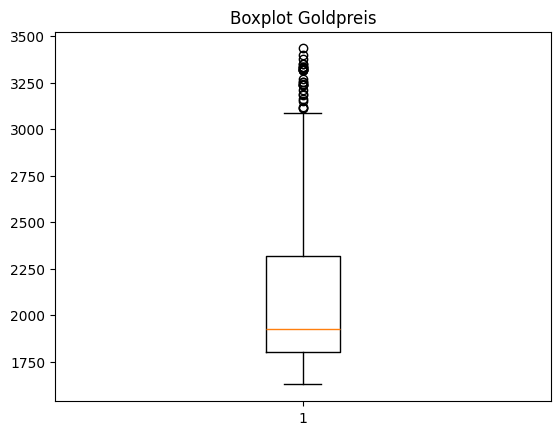

Anzahl an Outliern:1107


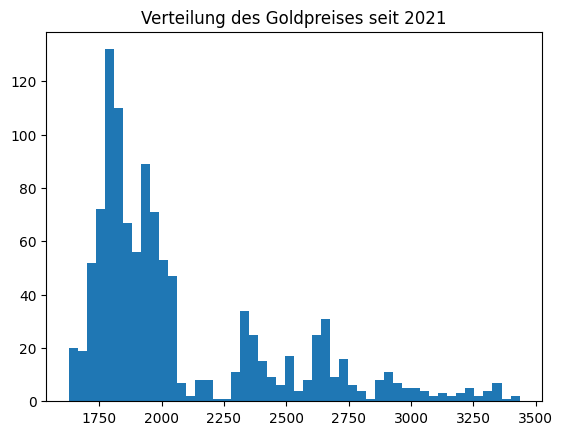

<Figure size 640x480 with 0 Axes>

In [31]:
#Boxplot für Überblick
plt.boxplot(df_goldpreis)
plt.title('Boxplot Goldpreis')
plt.show()
plt.clf()

#Ausreißer finden
def find_outliers_IQR(df):
   q1=df.quantile(0.25)
   q3=df.quantile(0.75)
   IQR=q3-q1
   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]
   return outliers

print('Anzahl an Outliern:' + str(len(find_outliers_IQR(df_goldpreis))))
# print(find_outliers_IQR(df_goldpreis))
# --> Online Abgleich: nur plausible Werte

plt.title('Verteilung des Goldpreises seit 2021')
plt.hist(df_goldpreis, bins=50)
plt.show()
plt.clf()

##Goldpreis im Zeitverlauf

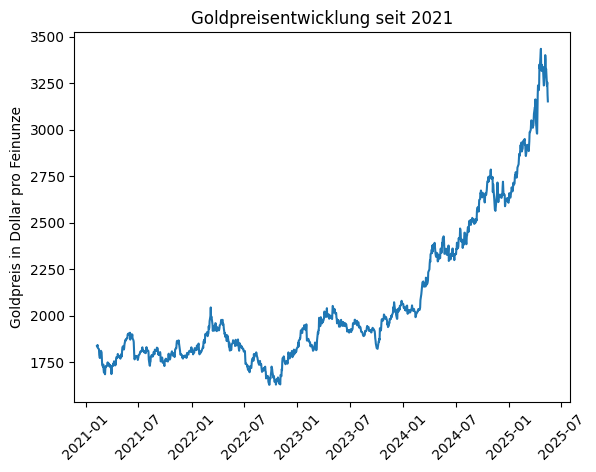

<Figure size 640x480 with 0 Axes>

In [32]:
# Goldpreisentwicklung
ax = plt.subplot(1, 1, 1)
plt.title('Goldpreisentwicklung seit 2021')
plt.plot(df_goldpreis)
plt.ylabel('Goldpreis in Dollar pro Feinunze')
plt.xticks(rotation=45)
plt.show()
plt.clf()

##ACF-PACF Plots

<Figure size 1200x600 with 0 Axes>

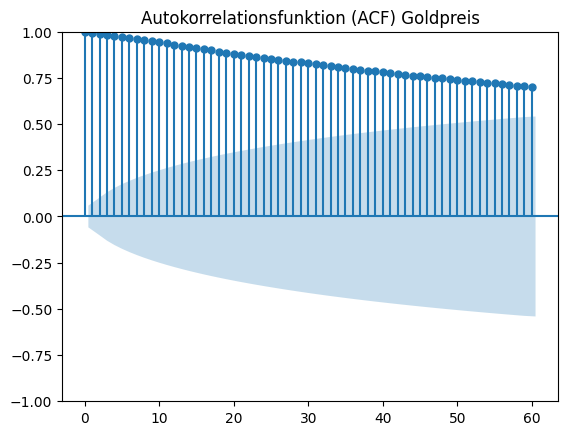

<Figure size 1200x600 with 0 Axes>

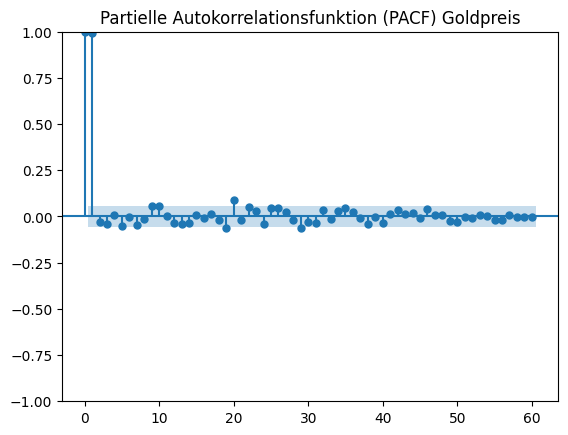

In [33]:
# Plotten der ACF und PACF
plt.figure(figsize=(12, 6))
plot_acf(df_goldpreis, lags=60, alpha=0.05)
plt.title('Autokorrelationsfunktion (ACF) Goldpreis')
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(df_goldpreis, lags=60, alpha=0.05)
plt.title('Partielle Autokorrelationsfunktion (PACF) Goldpreis')
plt.show()#

##Stationarität prüfen

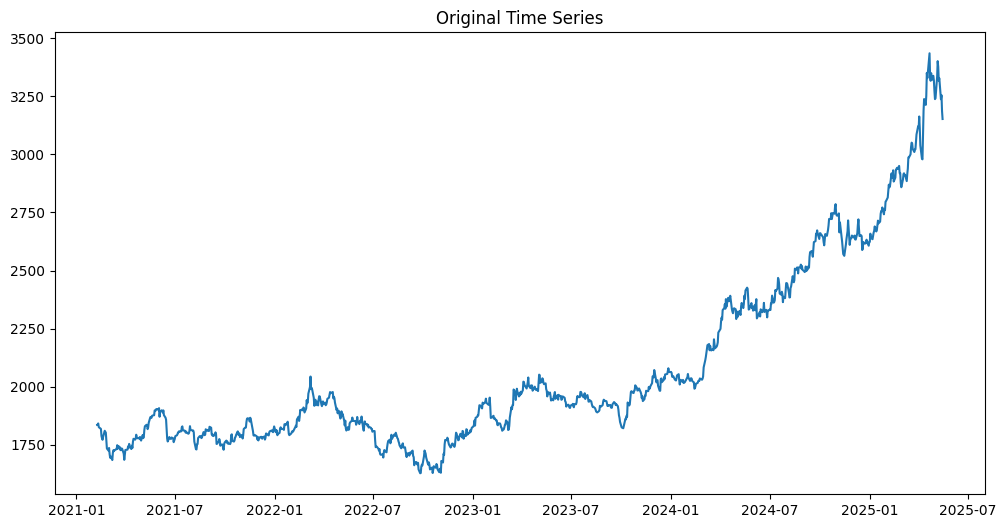

ADF-Test für die ursprüngliche Zeitreihe:
ADF Statistic: -3.4452967170058515
p-value: 0.00950828630907152
Critical Values:
	1%: -3.436287110400734
	5%: -2.864161528982321
	10%: -2.5681657829565743


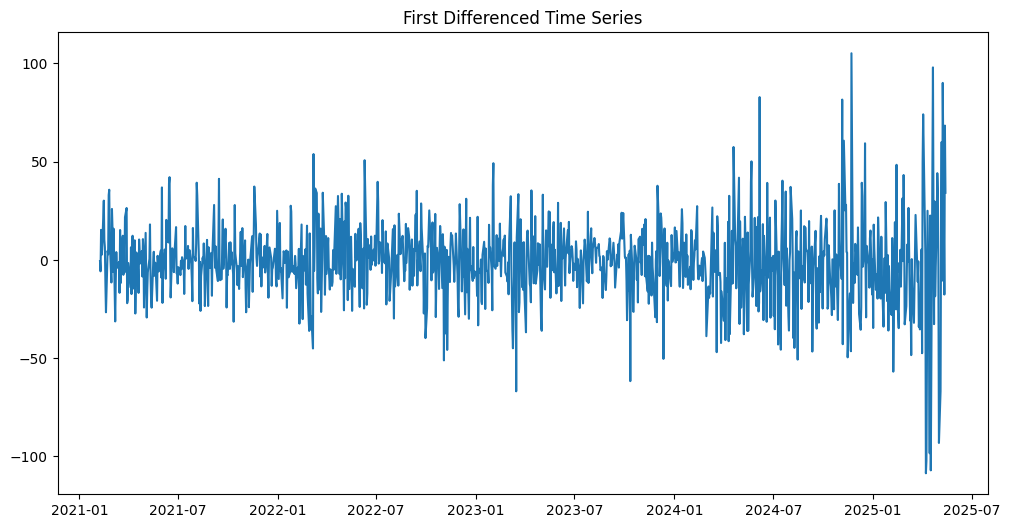


ADF-Test für die erste Differenzierung:
ADF Statistic: -23.9893781599648
p-value: 0.0
Critical Values:
	1%: -3.436287110400734
	5%: -2.864161528982321
	10%: -2.5681657829565743


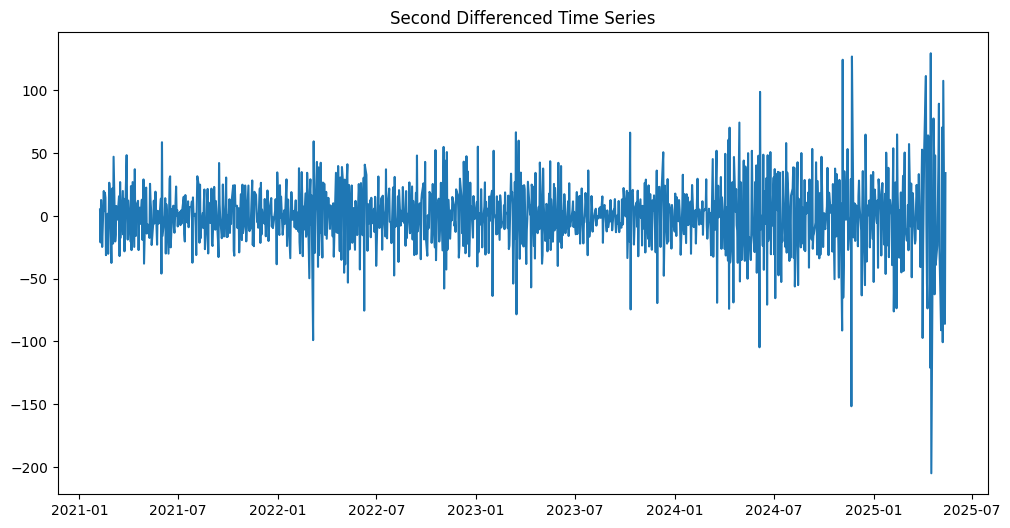


ADF-Test für die zweite Differenzierung:
ADF Statistic: -12.212684825057519
p-value: 1.1541571786837552e-22
Critical Values:
	1%: -3.436402509014354
	5%: -2.8642124318084456
	10%: -2.568192893555997


<Figure size 1200x600 with 0 Axes>

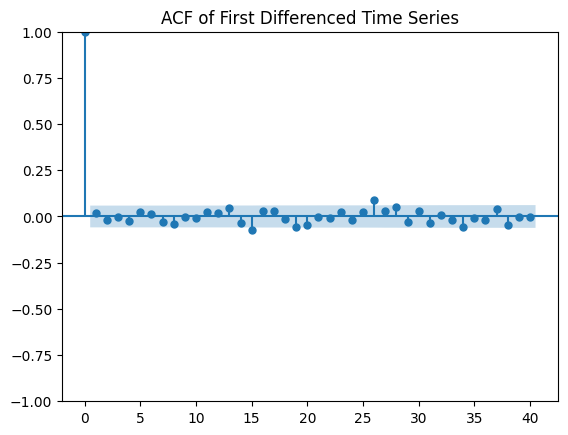

<Figure size 1200x600 with 0 Axes>

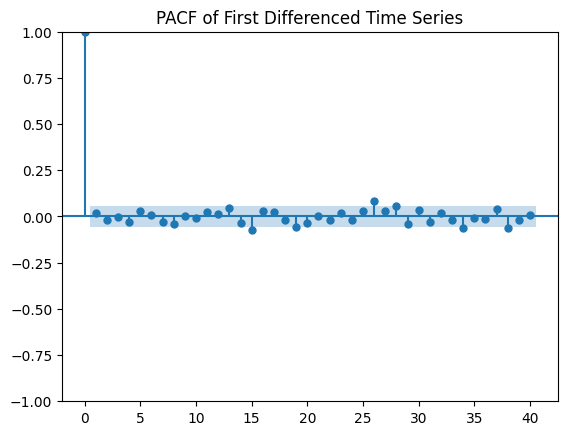

In [34]:
# Funktion zum ADF-Test
def adf_test(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

# Plot der ursprünglichen Zeitreihe
plt.figure(figsize=(12, 6))
plt.plot(df_goldpreis)
plt.title('Original Time Series')
plt.show()

# ADF-Test für die ursprüngliche Zeitreihe
print("ADF-Test für die ursprüngliche Zeitreihe:")
adf_test(df_goldpreis)

# ADF zeigt Stationarität an, aber aus der Analyse ist zu entnehmen, dass es nicht stationär ist

# Erste Differenzierung
first_diff = df_goldpreis.diff().dropna()

# Plot der ersten Differenzierung
plt.figure(figsize=(12, 6))
plt.plot(first_diff)
plt.title('First Differenced Time Series')
plt.show()

# ADF-Test für die erste Differenzierung
print("\nADF-Test für die erste Differenzierung:")
adf_test(first_diff)

# Jetzt ist es stationär, aber die Varianz nimmt im Zeitverlauf zu. Daher 2. Differenzierung.

# Zweite Differenzierung
second_diff = first_diff.diff().dropna()

# Plot der zweiten Differenzierung
plt.figure(figsize=(12, 6))
plt.plot(second_diff)
plt.title('Second Differenced Time Series')
plt.show()

# ADF-Test für die zweite Differenzierung
print("\nADF-Test für die zweite Differenzierung:")
adf_test(second_diff)

# Plot der ACF und PACF für die differenzierten Zeitreihen
plt.figure(figsize=(12, 6))
plot_acf(first_diff, lags=40, alpha=0.05)
plt.title('ACF of First Differenced Time Series')
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(first_diff, lags=40, alpha=0.05)
plt.title('PACF of First Differenced Time Series')
plt.show()

##Goldpreis nach Wochentagen

   Wochentag  Goldpreis_am_Tag
0          0       2072.229372
1          1       2073.948655
2          2       2076.090897
3          3       2079.692500
4          4       2071.298588


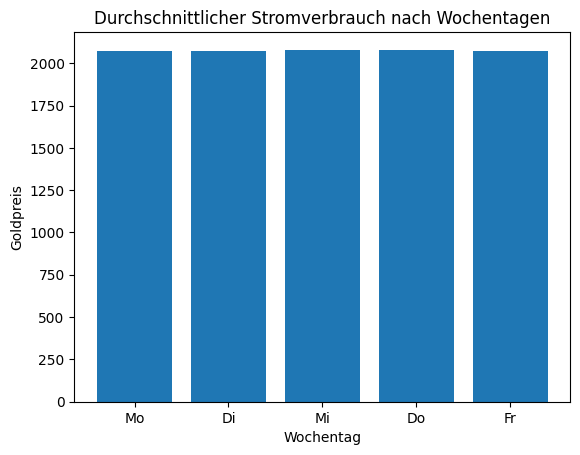

<Figure size 640x480 with 0 Axes>

In [35]:
# Wochentag: Montag = 0 .. Sonntag = 6
df_goldpreis['Wochentag'] = df_goldpreis.index.weekday
#Mittelwert für gesamtverbrauch pro Wochentag
mean_per_weekday = df_goldpreis.groupby('Wochentag')['Goldpreis_am_Tag'].mean().reset_index()
print(mean_per_weekday)

# Balkendiagramm erstellen
ax = plt.subplot(1,1,1)
plt.bar(mean_per_weekday['Wochentag'], mean_per_weekday['Goldpreis_am_Tag'])
plt.title('Durchschnittlicher Stromverbrauch nach Wochentagen')
plt.xlabel('Wochentag')
plt.ylabel('Goldpreis')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['Mo', 'Di', 'Mi', 'Do', 'Fr'])
plt.show()
plt.clf()

##Goldpreis nach Monat
##Innerhalb von kürzerem Zeitraum oder vgl. mit Wochenmittel

    Monat  Goldpreis_am_Tag
0       1       2123.637809
1       2       2102.058958
2       3       2132.356955
3       4       2260.336553
4       5       2155.322800
5       6       1976.829419
6       7       1979.784483
7       8       1981.917389
8       9       1980.477093
9      10       2032.241395
10     11       2039.256782
11     12       2066.899885


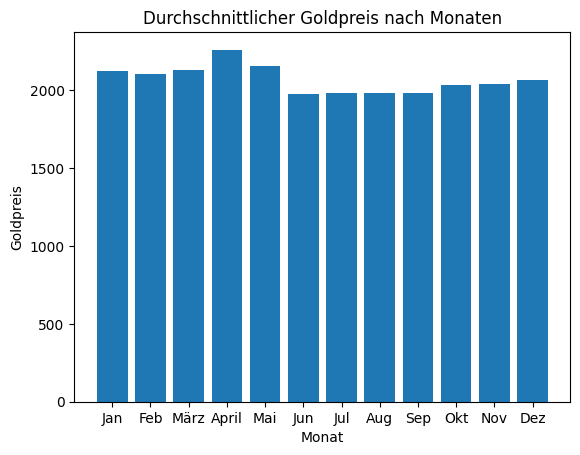

<Figure size 640x480 with 0 Axes>

In [36]:
# Wochentag: Montag = 0 .. Sonntag = 6
df_goldpreis['Monat'] = df_goldpreis.index.month
#Mittelwert für gesamtverbrauch pro Wochentag
mean_per_month = df_goldpreis.groupby('Monat')['Goldpreis_am_Tag'].mean().reset_index()
mean_months = mean_per_month['Goldpreis_am_Tag'].mean()
# mean_per_weekday.loc[len(mean_per_weekday.index)] = [7, mean_weekdays]
print(mean_per_month)

# Balkendiagramm erstellen
ax = plt.subplot(1,1,1)
plt.bar(mean_per_month['Monat'], mean_per_month['Goldpreis_am_Tag'])
plt.title('Durchschnittlicher Goldpreis nach Monaten')
plt.xlabel('Monat')
plt.ylabel('Goldpreis')
ax.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
ax.set_xticklabels(['Jan', 'Feb', 'März', 'April', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez'])
plt.show()
plt.clf()

##Goldpreis nach Wochentag und Monat

Januar
   Wochentag  Goldpreis_am_Tag
0          0       2078.589211
1          1       2100.190556
2          2       2139.848056
3          3       2150.641471
4          4       2154.645294


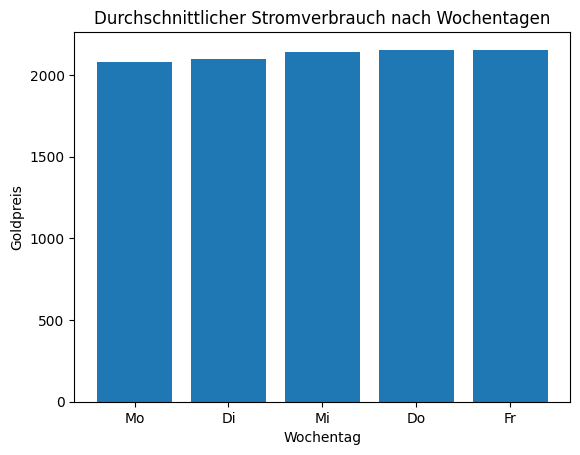

Februar
   Wochentag  Goldpreis_am_Tag
0          0       2106.483158
1          1       2098.537368
2          2       2108.210789
3          3       2100.633250
4          4       2096.505263


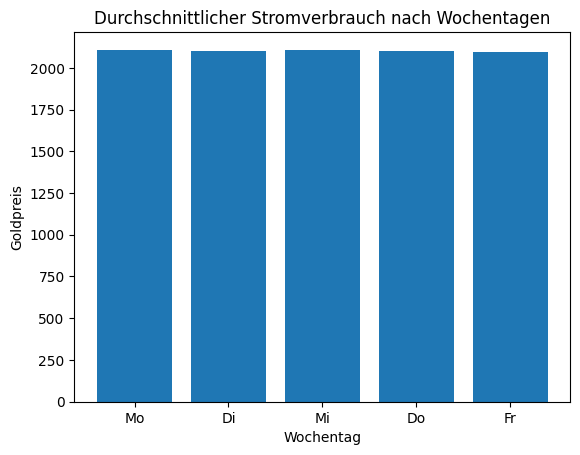

März
   Wochentag  Goldpreis_am_Tag
0          0       2165.287273
1          1       2112.497500
2          2       2109.005652
3          3       2133.983636
4          4       2142.534762


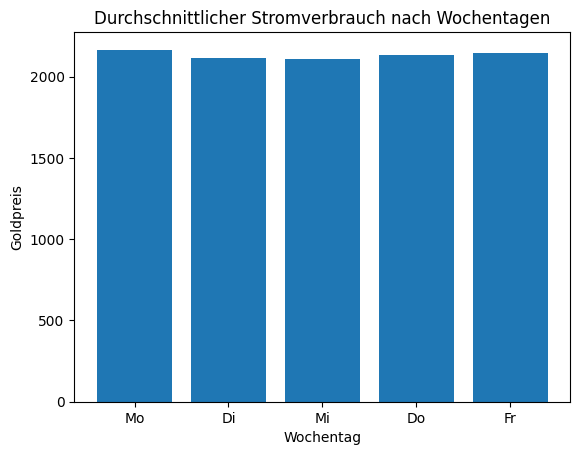

April
   Wochentag  Goldpreis_am_Tag
0          0       2254.534048
1          1       2293.186136
2          2       2301.218571
3          3       2235.676190
4          4       2208.031389


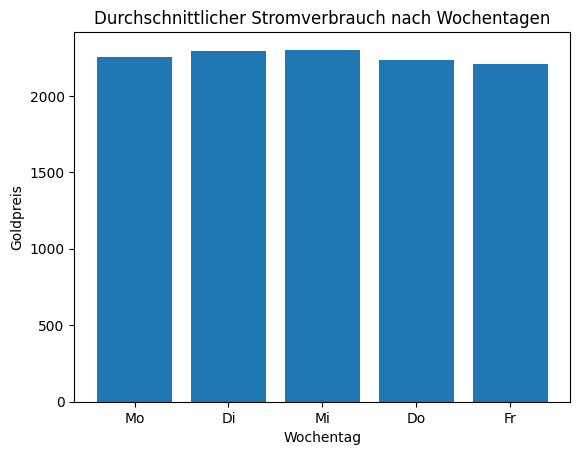

Mai
   Wochentag  Goldpreis_am_Tag
0          0       2117.752143
1          1       2134.393500
2          2       2154.228250
3          3       2208.967500
4          4       2163.563158


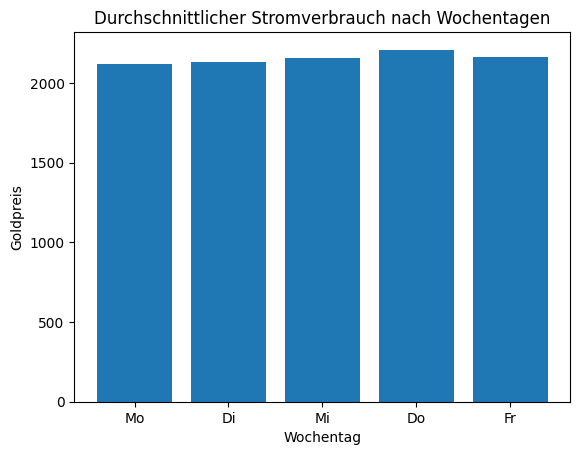

Juni
   Wochentag  Goldpreis_am_Tag
0          0       1984.975312
1          1       1973.955294
2          2       1965.957778
3          3       1978.516944
4          4       1981.761176


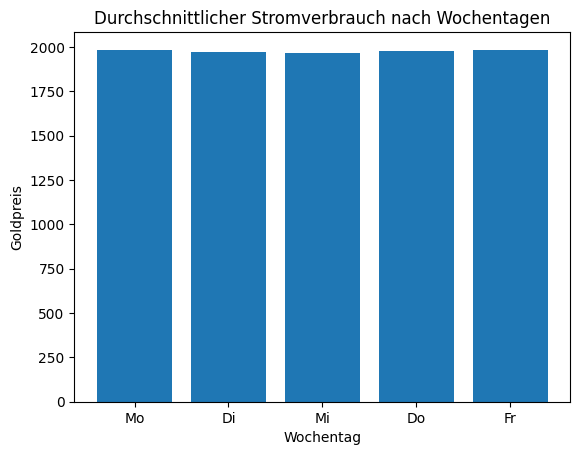

Juli
   Wochentag  Goldpreis_am_Tag
0          0       1988.454444
1          1       1995.460588
2          2       2000.629118
3          3       1961.351471
4          4       1954.031667


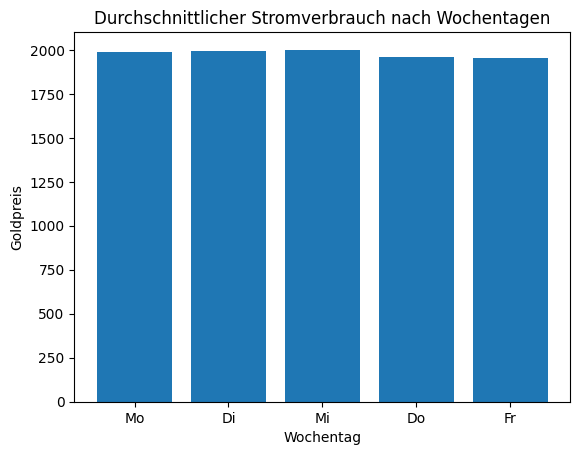

August
   Wochentag  Goldpreis_am_Tag
0          0       1962.352222
1          1       1960.070789
2          2       1965.994722
3          3       2008.768889
4          4       2015.478529


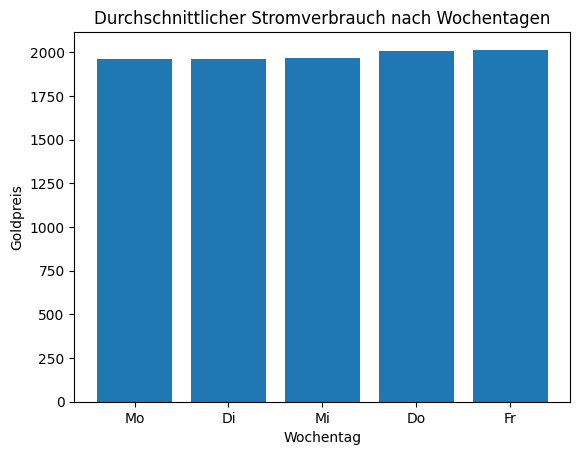

September
   Wochentag  Goldpreis_am_Tag
0          0       2025.649118
1          1       1983.020937
2          2       1969.994706
3          3       1956.699722
4          4       1969.230833


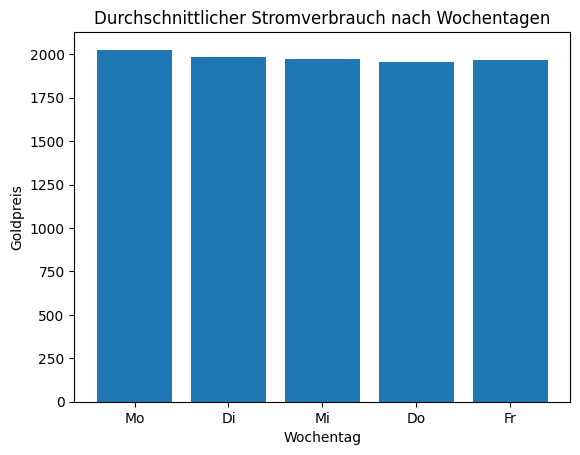

Oktober
   Wochentag  Goldpreis_am_Tag
0          0       1985.286389
1          1       2044.817778
2          2       2053.262059
3          3       2080.606563
4          4       2002.101471


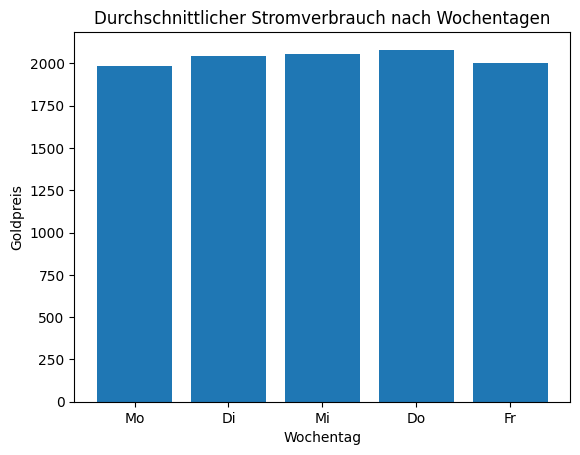

November
   Wochentag  Goldpreis_am_Tag
0          0       2029.551176
1          1       2013.548333
2          2       2021.013056
3          3       2043.976765
4          4       2090.780000


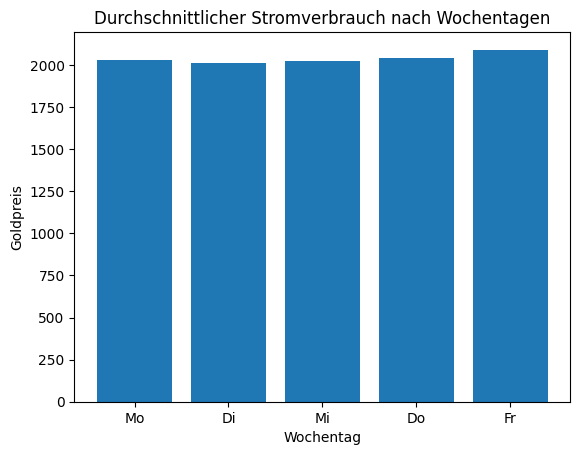

Dezember
   Wochentag  Goldpreis_am_Tag
0          0       2093.456471
1          1       2100.097647
2          2       2054.016176
3          3       2037.219444
4          4       2052.313611


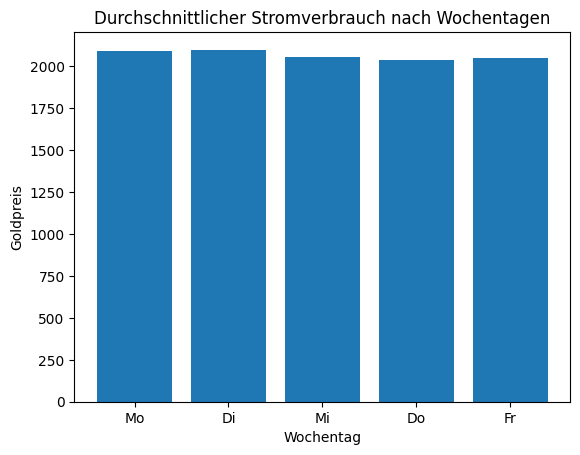

<Figure size 640x480 with 0 Axes>

In [37]:
def Balkendiagramm_Wochentag(data, Monat):
    data = data[data['Monat'] == Monat]
    mean_per_weekday = data.groupby('Wochentag')['Goldpreis_am_Tag'].mean().reset_index()
    print(mean_per_weekday)

    # Balkendiagramm erstellen
    ax = plt.subplot(1,1,1)
    plt.bar(mean_per_weekday['Wochentag'], mean_per_weekday['Goldpreis_am_Tag'])
    plt.title('Durchschnittlicher Stromverbrauch nach Wochentagen')
    plt.xlabel('Wochentag')
    plt.ylabel('Goldpreis')
    ax.set_xticks([0, 1, 2, 3, 4]) 
    ax.set_xticklabels(['Mo', 'Di', 'Mi', 'Do', 'Fr'])
    plt.show()
    plt.clf()

Mon = ['Januar', 'Februar', 'März', 'April', 'Mai', 'Juni', 'Juli', 'August', 'September', 'Oktober', 'November', 'Dezember']
Monate = range(1, 13)

for month, Monat in zip(Mon, Monate):
    print(month)
    Balkendiagramm_Wochentag(df_goldpreis, Monat)

##ARIMA Modell mit Train-/Test Split

MSE für den Goldpreis: 121674.77119294288


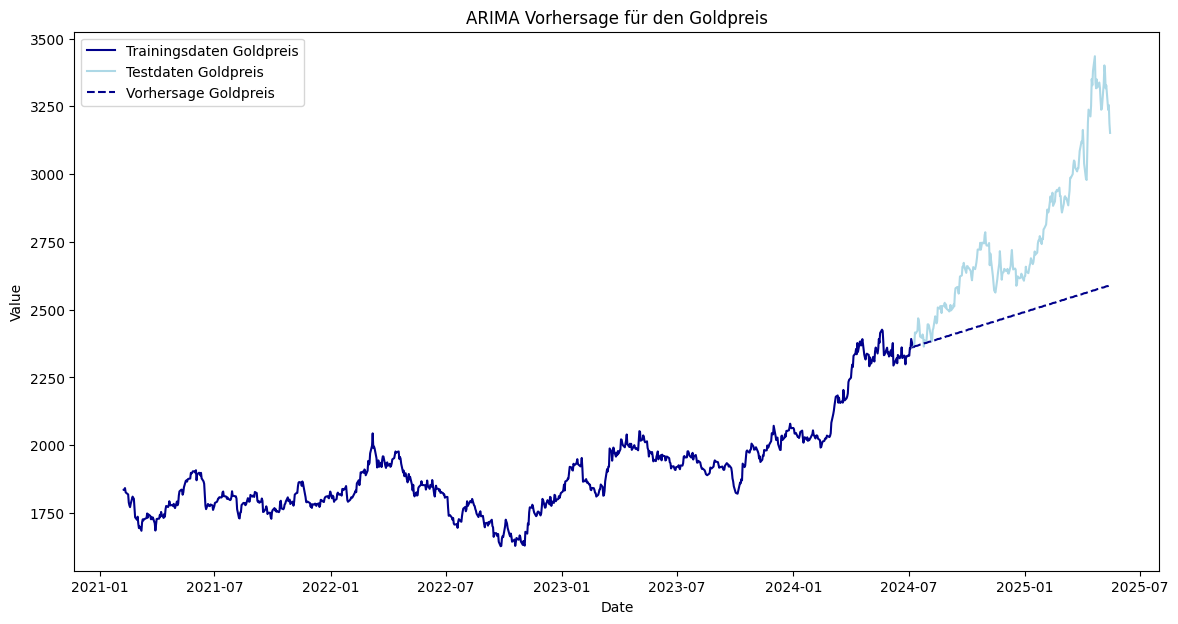

In [38]:
df_goldpreis = df_goldpreis.sort_index()
df_goldpreis = df_goldpreis.asfreq('B')
df_goldpreis = df_goldpreis.interpolate(method='linear')
df_goldpreis.index.freq = 'B'


# Aufteilen in Trainingsdaten und Testdaten
train_size = int(0.8 * len(df_goldpreis))
train, test = df_goldpreis[:train_size], df_goldpreis[train_size:]

# ARIMA Modell fitten
arima_model_Goldpreis = ARIMA(train['Goldpreis_am_Tag'], order=(3, 2, 2))
arima_model_Goldpreis_fit = arima_model_Goldpreis.fit()

# Vorhersage für die Testdaten
arima_forecast_Goldpreis = arima_model_Goldpreis_fit.forecast(steps=len(test))

# MSE berechnen
mse_Goldpreis = mean_squared_error(test['Goldpreis_am_Tag'], arima_forecast_Goldpreis)

# Ergebnisse anzeigen
print(f'MSE für den Goldpreis: {mse_Goldpreis}')


# Plot für die Vorhersage des Goldpreises
plt.figure(figsize=(14, 7))
plt.plot(train['Goldpreis_am_Tag'], color='darkblue', label='Trainingsdaten Goldpreis')
plt.plot(test.index, test['Goldpreis_am_Tag'], color='lightblue', label='Testdaten Goldpreis')
plt.plot(test.index, arima_forecast_Goldpreis, color='darkblue', linestyle='--', label='Vorhersage Goldpreis')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('ARIMA Vorhersage für den Goldpreis')
plt.legend()
plt.show()

##Hyperparameter Tuning

In [39]:
sweep_config = {'method': 'random'}
metric = { 'name': 'MSE', 'goal': 'minimize'}

sweep_config['metric'] = metric

parameters_dict = {
    'order': {
        'values': [(1, 1, 1), (1, 2, 1), (2, 2, 2)]
        }
    }

sweep_config['parameters'] = parameters_dict

sweep_id = wandb.sweep(sweep_config)


df_goldpreis = df_goldpreis.sort_index()
df_goldpreis = df_goldpreis.asfreq('B')
df_goldpreis = df_goldpreis.interpolate(method='linear')
df_goldpreis.index.freq = 'B'


# Aufteilen in Trainingsdaten und Testdaten
train_size = int(0.8 * len(df_goldpreis))
train, test = df_goldpreis[:train_size], df_goldpreis[train_size:]

def training():
    wandb.init()
    order = wandb.config.order
    global train, test
    
    # ARIMA Modell fitten
    arima_model_Goldpreis = ARIMA(train['Goldpreis_am_Tag'], order=(order))
    arima_model_Goldpreis_fit = arima_model_Goldpreis.fit()

    # Vorhersage für die Testdaten
    arima_forecast_Goldpreis = arima_model_Goldpreis_fit.forecast(steps=len(test))

    # MSE berechnen
    mse_Goldpreis = mean_squared_error(test['Goldpreis_am_Tag'], arima_forecast_Goldpreis)
    
    wandb.log({"MSE": mse_Goldpreis})
    
    # Ergebnisse anzeigen
    print(f'MSE für den Goldpreis: {mse_Goldpreis}')

wandb.agent(sweep_id, function=training, count=10)  # z.B. 10 Runs

# Parameter anpassen
# Vorhersagen verbessern

Create sweep with ID: l7yxwedw
Sweep URL: https://wandb.ai/johannes-johannes-anhalt-university-of-applied-sciences/uncategorized/sweeps/l7yxwedw


wandb: Agent Starting Run: psz9w7bb with config:
wandb: 	order: [1, 2, 1]


MSE für den Goldpreis: 132474.30944007478


MSE,▁
MSE,132474.30944


wandb: Agent Starting Run: tbfph6iw with config:
wandb: 	order: [2, 2, 2]


...

MSE für den Goldpreis: 124012.84847875874


MSE,▁
MSE,124012.84848


wandb: Agent Starting Run: f6u5v62f with config:
wandb: 	order: [1, 2, 1]


MSE für den Goldpreis: 132474.30944007478


MSE,▁
MSE,132474.30944
